## **Community Help via Multivariate Anomaly Detection**
In this notebook, we will try to help a community which has severe problems with failures of a pump system through applying multivariate time series anomaly detection. The inquiry for help came through the post of the [dataset](https://www.kaggle.com/datasets/nphantawee/pump-sensor-data) itself, so let us hope that we may be able to improve the living conditions of some people through data science in the following.

In detail, this notebook contains:
* EDA and data preparation
* Model training, validation and selection using the ADTK library
* Model testing
* Conclusion

Based on this, let us start without any further holdup :)!

## **Importing/Installing Libraries**

In [1]:
!pip install adtk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.2 MB/s eta 0:00:00


In [2]:
# Import code
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## **Config**
Set build_plots_full to True if you want all plots to be built (takes some time however):

In [3]:
build_plots_full = False

## **Exploratory Data Analysis (EDA) and Data Preparation**
Let's first get a quick overview over the dataset:

In [4]:
df = pd.read_csv('/kaggle/input/sensor.csv')
df.head()

,Unnamed: 0,timestamp,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,...,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51,machine_status
0,0,2018-04-01 00:00:00,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,...,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
1,1,2018-04-01 00:01:00,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,...,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
2,2,2018-04-01 00:02:00,2.444734,47.35243,53.2118,46.397570,638.8889,73.54598,13.32465,16.03733,...,41.66666,39.351852,65.39352,51.21528,38.194443,155.9606,67.12963,241.3194,203.7037,NORMAL
3,3,2018-04-01 00:03:00,2.460474,47.09201,53.1684,46.397568,628.1250,76.98898,13.31742,16.24711,...,40.88541,39.062500,64.81481,51.21528,38.194440,155.9606,66.84028,240.4514,203.1250,NORMAL
4,4,2018-04-01 00:04:00,2.445718,47.13541,53.2118,46.397568,636.4583,76.58897,13.35359,16.21094,...,41.40625,38.773150,65.10416,51.79398,38.773150,158.2755,66.55093,242.1875,201.3889,NORMAL


We can see that the dataset contains the raw data from 52 sensors of the pump system, a time column and a column representing the status of the pump system. We can also see that we can remove the first column since it only contains redundant information:

In [5]:
df.drop(df.columns[0], axis=1, inplace=True)

Let's also print some basic statistics of the dataset:

In [6]:
df.shape

(220320, 54)

In [7]:
df.describe()

,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,sensor_08,sensor_09,...,sensor_42,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51
count,210112.000000,219951.000000,220301.000000,220301.000000,220301.000000,220301.000000,215522.000000,214869.000000,215213.000000,215725.000000,...,220293.000000,220293.000000,220293.000000,220293.000000,220293.000000,220293.000000,220293.000000,220293.000000,143303.000000,204937.000000
mean,2.372221,47.591611,50.867392,43.752481,590.673936,73.396414,13.501537,15.843152,15.200721,14.799210,...,35.453455,43.879591,42.656877,43.094984,48.018585,44.340903,150.889044,57.119968,183.049260,202.699667
std,0.412227,3.296666,3.666820,2.418887,144.023912,17.298247,2.163736,2.201155,2.037390,2.091963,...,10.259521,11.044404,11.576355,12.837520,15.641284,10.442437,82.244957,19.143598,65.258650,109.588607
min,0.000000,0.000000,33.159720,31.640620,2.798032,0.000000,0.014468,0.000000,0.028935,0.000000,...,22.135416,24.479166,25.752316,26.331018,26.331018,27.199070,26.331018,26.620370,27.488426,27.777779
25%,2.438831,46.310760,50.390620,42.838539,626.620400,69.976260,13.346350,15.907120,15.183740,15.053530,...,32.812500,39.583330,36.747684,36.747684,40.509258,39.062500,83.912030,47.743060,167.534700,179.108800
50%,2.456539,48.133678,51.649300,44.227428,632.638916,75.576790,13.642940,16.167530,15.494790,15.082470,...,35.156250,42.968750,40.509260,40.219910,44.849540,42.534720,138.020800,52.662040,193.865700,197.338000
75%,2.499826,49.479160,52.777770,45.312500,637.615723,80.912150,14.539930,16.427950,15.697340,15.118630,...,36.979164,46.614580,45.138890,44.849540,51.215280,46.585650,208.333300,60.763890,219.907400,216.724500
max,2.549016,56.727430,56.032990,48.220490,800.000000,99.999880,22.251160,23.596640,24.348960,25.000000,...,374.218800,408.593700,1000.000000,320.312500,370.370400,303.530100,561.632000,464.409700,1000.000000,1000.000000


In [8]:
df.isnull().sum()

timestamp              0
sensor_00          10208
sensor_01            369
sensor_02             19
sensor_03             19
sensor_04             19
sensor_05             19
sensor_06           4798
sensor_07           5451
sensor_08           5107
sensor_09           4595
sensor_10             19
sensor_11             19
sensor_12             19
sensor_13             19
sensor_14             21
sensor_15         220320
sensor_16             31
sensor_17             46
sensor_18             46
sensor_19             16
sensor_20             16
sensor_21             16
sensor_22             41
sensor_23             16
sensor_24             16
sensor_25             36
sensor_26             20
sensor_27             16
sensor_28             16
sensor_29             72
sensor_30            261
sensor_31             16
sensor_32             68
sensor_33             16
sensor_34             16
sensor_35             16
sensor_36             16
sensor_37             16
sensor_38             27


Several rows of the dataset contain NANs. We remove the column of sensor_15 since it only consists of NaNs and fill the rest of the missing values with the last valid value of the time series (since we could also use this imputation at prediction time):

In [9]:
df.drop(['sensor_15'], axis=1, inplace=True)
df.fillna(method='ffill', inplace=True)

Let's now have a closer look at the machine_status column and check all values it contains:

In [10]:
df['machine_status'].unique()

array(['NORMAL', 'BROKEN', 'RECOVERING'], dtype=object)

We can see that there are three different possible values for this column. From the dataset description we can find out that 'NORMAL' labels the timesteps as having no anomaly (as the name suggests ;)), 'BROKEN' means that there is an anomaly in the respective timestep and 'RECOVERING' means that the pump system is recovering from an anomaly (directly after an anomaly) in the current timestep. Let's encode these values through replacing them with numbers from 0 to 2 and let's also convert the timestamp column to datetime objects for the next steps:

In [11]:
# encode machine status column and convert timestamp column to datetime objects
df.replace({'machine_status': {'RECOVERING': 2, 'BROKEN': 1, 'NORMAL': 0}}, inplace=True)
df['timestamp'] = pd.to_datetime(df['timestamp'])

Next, we also print the start and end time of our data for a better overview:

In [12]:
print('Start time: ', df['timestamp'].min())
print('End time: ', df['timestamp'].max())
print('Time difference: ', df['timestamp'].max()-df['timestamp'].min())

Start time:  2018-04-01 00:00:00
End time:  2018-08-31 23:59:00
Time difference:  152 days 23:59:00


Lastly for this EDA, let's plot the time series data (set build_plots_full to True in the config cell if you want to plot all signals) and the target label (machine_status) distribution. The 'normal' datapoints are plotted in **blue**, the 'broken' datapoints (anomalies) are plotted in **red** and the 'recovering' datapoints are plotted in **yellow**:

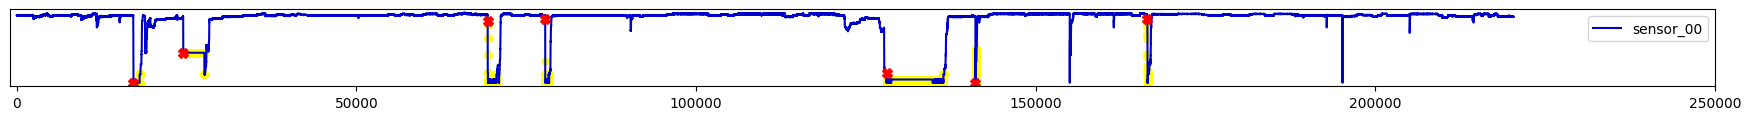

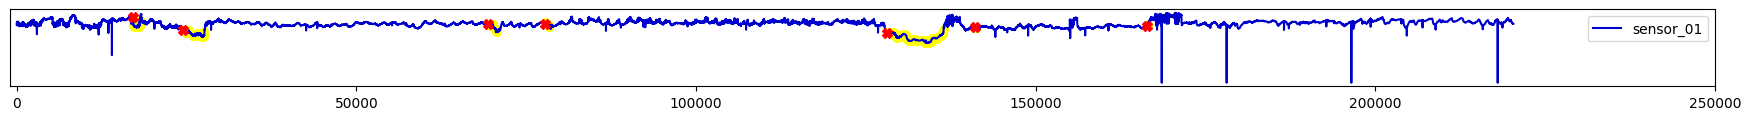

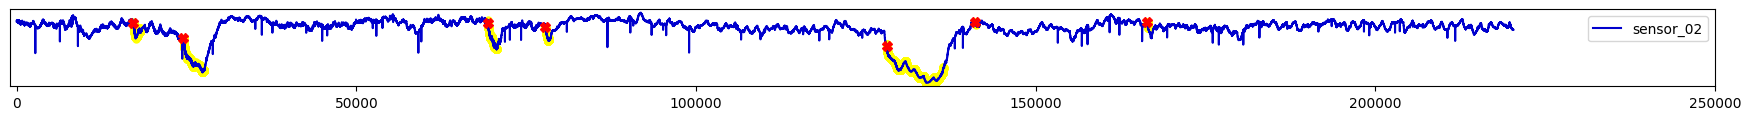

In [13]:
# this visualization was gratefully inspired by https://www.kaggle.com/code/mattison/water-pump-classification/notebook
if build_plots_full:
    col_names = df.columns[1:-1]
else:
    col_names = df.columns[1:4]

for col_name in col_names:
    plot = plt.figure(figsize=(22,1))
    plot = plt.plot(df[col_name].loc[df['machine_status'] == 2], linestyle='none', marker='o', color='yellow', markersize=5)
    plot = plt.plot(df[col_name], color='mediumblue', label=col_name)
    plot = plt.plot(df[col_name].loc[df['machine_status'] == 1], linestyle='none', marker='X', color='red', markersize=7)
    plt.legend(loc='upper right')
    plt.xlim((-1000,250000))
    frame1 = plt.gca()
    frame1.axes.get_yaxis().set_visible(False)
    plt.show()

<Axes: xlabel='machine_status', ylabel='count'>

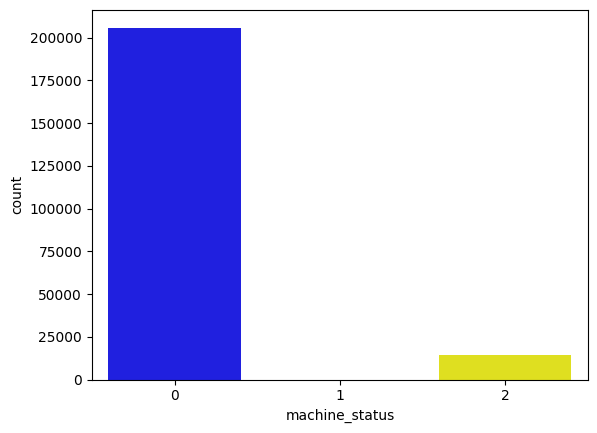

In [14]:
df['machine_status'].value_counts()
sns.countplot(x='machine_status',data=df,palette=['blue','red', 'yellow'])

We can see that some signals seem to be correlated, whereas others do not seem to show any correlation with other signals. We also see that the data contains 7 anomalies overall and that the recovering datapoints (as already mentioned above) always follow the anomalies. We can also clearly notice that the label distribution is heavily unbalanced.

## **Model Training, Validation and Selection**
In the following, we will now build a model for detecting these anomalies in order to be able to (automatically) react to the anomalies as fast as possible to e.g. prevent damage to the pump system. Based on this, in the future I would like to develop a model for predicting the anomalies so that it would be potentially possible to prevent the anomalies in the first place.

To have a clean and honest setup without data leakage, we will now define separate training, validation and test sets. We split the data in a way that we have 3 anomalies in our training set, 2 anomalies in our validation set and 2 anomalies in our test set (that is the reason for the weird fractions used for seperating the data):

In [15]:
df_train_split, df_test_split = np.split(df, [int(0.63 *len(df))])
df_train_split, df_valid_split = np.split(df_train_split, [int(0.54 *len(df_train_split))])

### **Training**
Before we start developing the anomaly detection models, let's first plot the training data split...

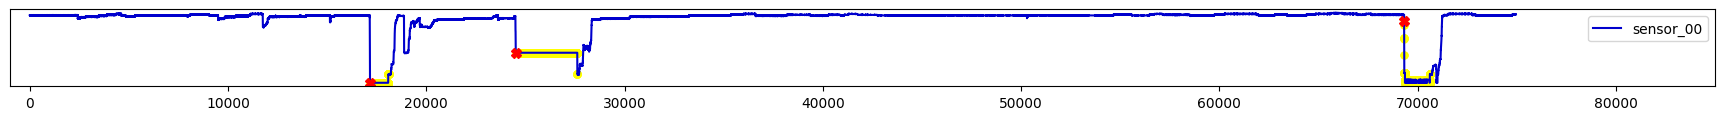

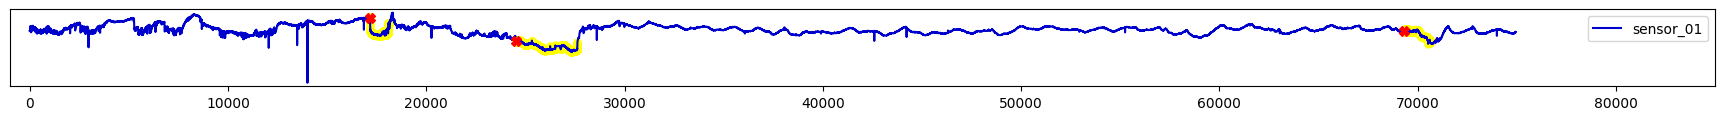

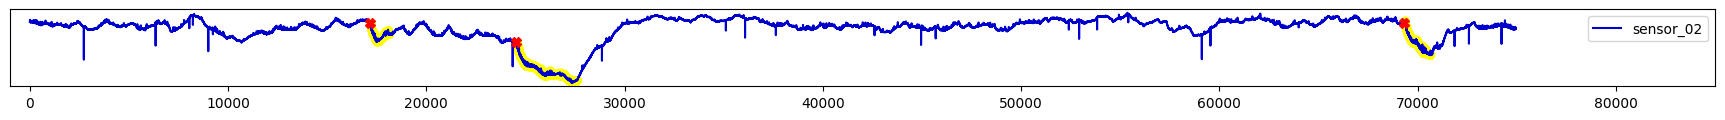

In [16]:
# this visualization was gratefully inspired by https://www.kaggle.com/code/mattison/water-pump-classification/notebook
if build_plots_full:
    col_names = df.columns[1:-1]
else:
    col_names = df.columns[1:4]
    
for col_name in col_names:
    plot = plt.figure(figsize=(22,1))
    plot = plt.plot(df_train_split[col_name].loc[df_train_split['machine_status'] == 2], linestyle='none', marker='o', color='yellow', markersize=5)
    plot = plt.plot(df_train_split[col_name], color='mediumblue', label=col_name)
    plot = plt.plot(df_train_split[col_name].loc[df_train_split['machine_status'] == 1], linestyle='none', marker='X', color='red', markersize=7)
    plt.legend(loc='upper right')
    plt.xlim((-1000,85000))
    frame1 = plt.gca()
    frame1.axes.get_yaxis().set_visible(False)
    plt.show()

...and let's also plot a correlation heatmap for all the signals:

<Axes: >

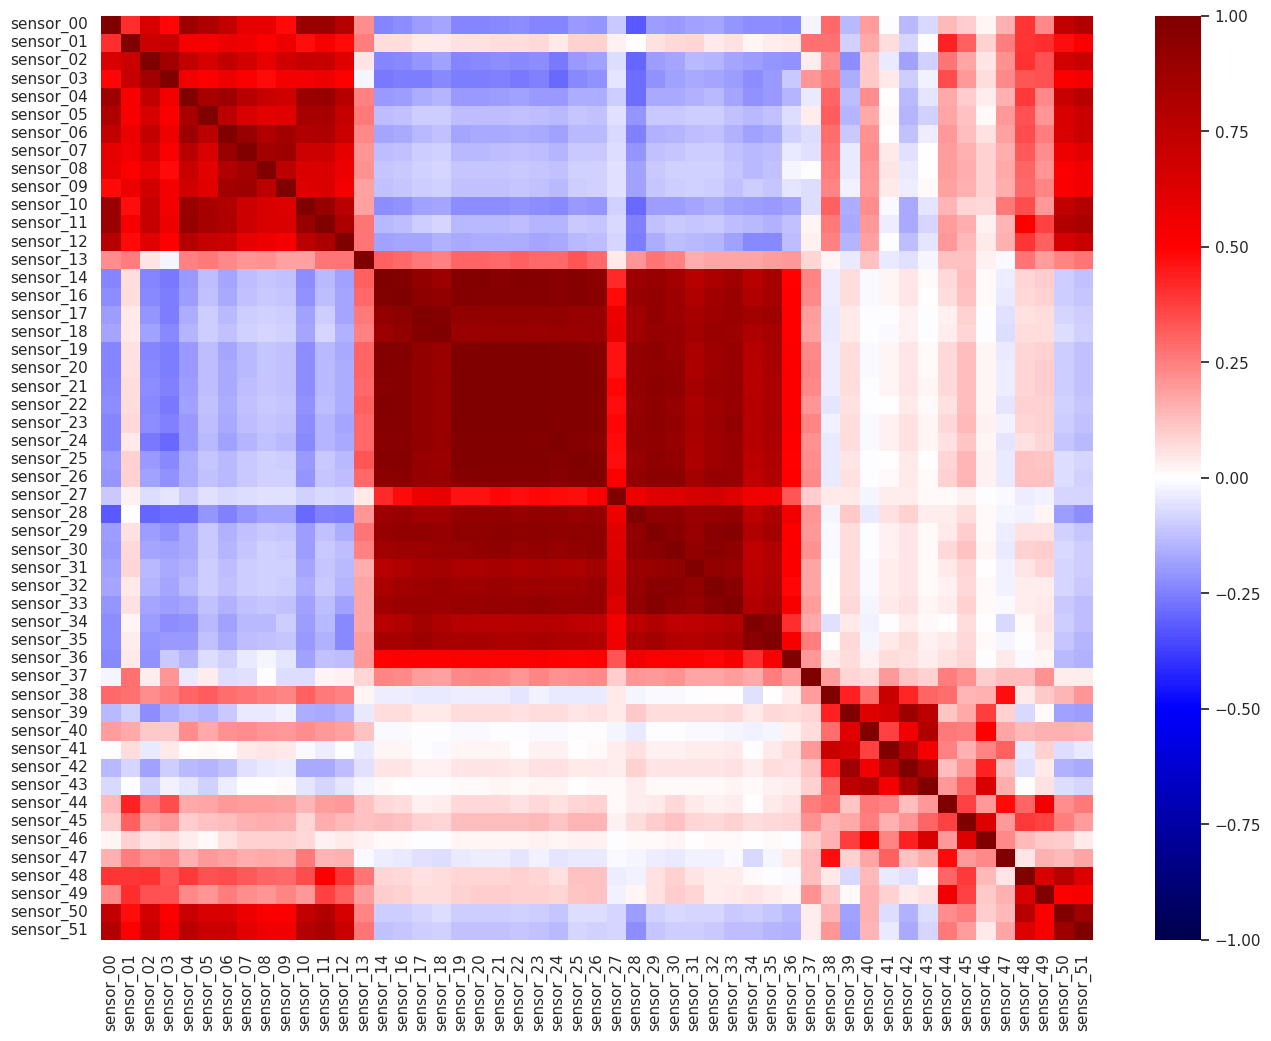

In [17]:
sns.set(rc={'figure.figsize':(16, 12)})
correlation=df_train_split.iloc[:, 1:-1].corr()
sns.heatmap(correlation, cmap='seismic', vmin=-1, vmax=1)

In the correlation heatmap, we can see that some signals are quite strongly correlated. This is important to keep in mind since the performance of some model types can suffer when the (independent) input variables are correlated with each other.

Before we now dive into the actual modeling part, let's first scale all our independent variables to the range (-1, 1):

In [18]:
# scale features to (-1, 1)
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(-1, 1))
df_train_split[df.columns[1:-1].to_list()] = scaler.fit_transform(df_train_split[df.columns[1:-1].to_list()])
df_valid_split[df.columns[1:-1].to_list()] = scaler.transform(df_valid_split[df.columns[1:-1].to_list()])
df_test_split[df.columns[1:-1].to_list()] = scaler.transform(df_test_split[df.columns[1:-1].to_list()])

Ok, cool, we are now ready to train some machine learning models :)! For this part, we will train and compare several models from the python library [ADTK](https://adtk.readthedocs.io/en/stable/) which is specialized on time series anomaly detection.

In order to use the library, we first prepare our time series data through a function called 'validate_series':

In [19]:
from adtk.data import validate_series
s_train = validate_series(df_train_split.set_index('timestamp'))
s_valid = validate_series(df_valid_split.set_index('timestamp'))

In the following, we will train several model types for multivariate time series anomaly detection on the training data and then detect anomalies with them on the validation data. In this context, we use the validation data to (manually) optimize the hyperparameters of the models (the hyperparameters used in the models below are already the optimized ones from me). It is important that we do not use the test data in this step in any way because we want to keep the test data for honestly testing the generalization capacities of the final model later on.

With this in mind, let's start with a pca-based detection model. The documentation of ADTK says about this model type: "This detector performs principal component analysis (PCA) to the multivariate time series (every time point is treated as a point in high- dimensional space), measures reconstruction error at every time point, and identifies a time point as anomalous when the recontruction error is beyond anomalously large" ([here](https://peterbloem.nl/blog/pca-2) some more information about the pca reconstruction error):

In [20]:
from adtk.detector import PcaAD
pca_ad = PcaAD(k=1, c=5.0)

outliers_train_pca = pca_ad.fit_detect(s_train).astype(int)
outliers_valid_pca = pca_ad.detect(s_valid).astype(int)
df_train_split['outliers_pca'] = outliers_train_pca.to_numpy()
df_valid_split['outliers_pca'] = outliers_valid_pca.to_numpy()

In addition, let's also train a clustering-based detector in combination with KMeans for clustering. From the docs: "This detector peforms clustering using a clustering model, and identifies a time points as anomalous if it belongs to the minimal cluster" ([here](https://en.wikipedia.org/wiki/K-means_clustering) some more information about KMeans):

In [21]:
from adtk.detector import MinClusterDetector
from sklearn.cluster import KMeans
min_cluster_ad = MinClusterDetector(KMeans(n_clusters=3))

outliers_train_mc = min_cluster_ad.fit_detect(s_train).astype(int)
outliers_valid_mc = min_cluster_ad.detect(s_valid).astype(int)
df_train_split['outliers_mc'] = outliers_train_mc.to_numpy()
df_valid_split['outliers_mc'] = outliers_valid_mc.to_numpy()

We also want to try the outlier detector in combination with the local outlier factor. The docs: "This detector peforms time-independent outlier detection using given model, and identifies a time points as anomalous if it is labelled as an outlier" ([here](https://en.wikipedia.org/wiki/Local_outlier_factor) some more information about the local outlier factor):

In [22]:
from adtk.detector import OutlierDetector
from sklearn.neighbors import LocalOutlierFactor
contamination = df_train_split['machine_status'].value_counts()[1]/(df_train_split['machine_status'].value_counts()[0]+df_train_split['machine_status'].value_counts()[2])
local_outlier_ad = OutlierDetector(LocalOutlierFactor(contamination=contamination))

outliers_train_lo = local_outlier_ad.fit_detect(s_train).astype(int)
outliers_valid_lo = local_outlier_ad.detect(s_valid).astype(int)
df_train_split['outliers_lo'] = outliers_train_lo.to_numpy()
df_valid_split['outliers_lo'] = outliers_valid_lo.to_numpy()

Last but not least, we also add regression anomaly detection to our models. Here, we now choose Ridge Regression over Linear Regression because Ridge Regression can handle correlated independent variables better than Linear Regression. From the docs: "This detector performs regression to build relationship between a target series and the rest of series, and identifies a time point as anomalous when the residual of regression is anomalously large" ([here](https://www.ncl.ac.uk/webtemplate/ask-assets/external/maths-resources/statistics/regression-and-correlation/residuals.html) some more information about regression residuals). Since the signal of "sensor_00" seems to be quite informative regarding the system anomalies (there are often changes in this signal before an anomaly), we choose this signal as the regression target:

In [23]:
from adtk.detector import RegressionAD
from sklearn.linear_model import Ridge
regression_ad = RegressionAD(regressor=Ridge(), target="sensor_00", c=6.0)

outliers_train_rg = regression_ad.fit_detect(s_train).astype(int)
outliers_valid_rg = regression_ad.detect(s_valid).astype(int)
df_train_split['outliers_rg'] = outliers_train_rg.to_numpy()
df_valid_split['outliers_rg'] = outliers_valid_rg.to_numpy()

In addition to using the regression anomaly detector, it is also interesting to have a look at the regression residuals itself. We also add these below:

In [24]:
from adtk.transformer import RegressionResidual
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
regression_residual_ad = RegressionResidual(regressor=Ridge(), target="sensor_00")

outliers_train_rgr = regression_residual_ad.fit_transform(s_train)
outliers_valid_rgr = regression_residual_ad.transform(s_valid)
df_train_split['outliers_rgr'] = outliers_train_rgr.to_numpy()
df_valid_split['outliers_rgr'] = outliers_valid_rgr.to_numpy()

Let's now visualize the detection results of all detectors in the following:

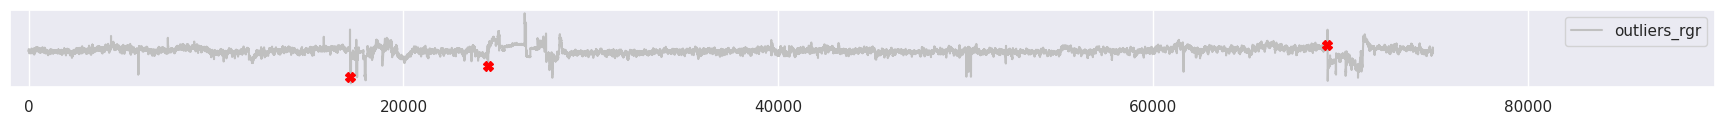

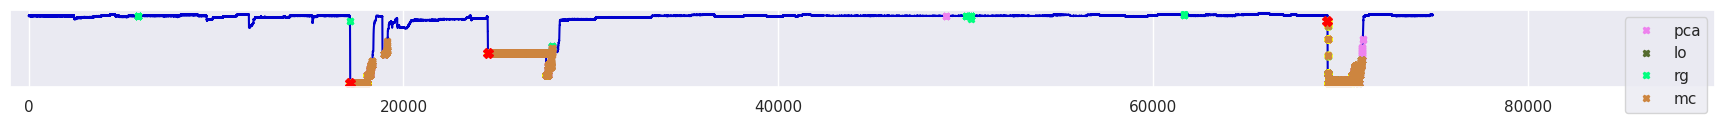

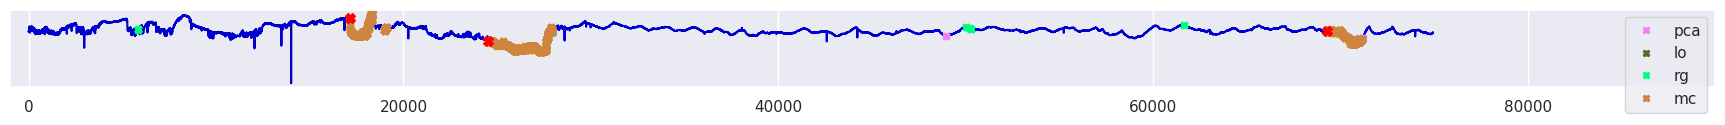

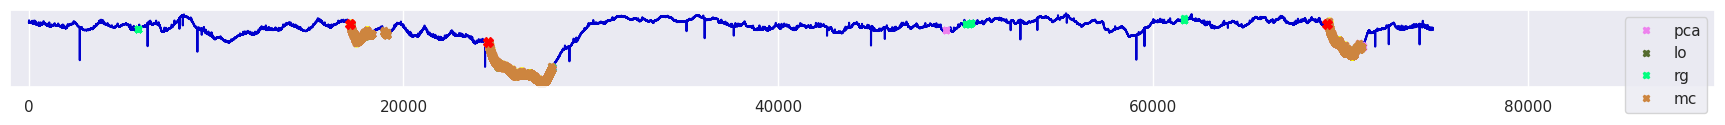

In [25]:
# this visualization was gratefully inspired by https://www.kaggle.com/code/mattison/water-pump-classification/notebook
plot = plt.figure(figsize=(22,1))
plot = plt.plot(df_train_split['outliers_rgr'], color='silver', label='outliers_rgr')
plot = plt.plot(df_train_split['outliers_rgr'].loc[df_train_split['machine_status'] == 1], linestyle='none', marker='X', color='red', markersize=7)
plt.legend(loc='upper right')
plt.xlim((-1000,90000))
frame1 = plt.gca()
frame1.axes.get_yaxis().set_visible(False)
plt.show()

if build_plots_full:
    col_names = df.columns[1:-1]
else:
    col_names = df.columns[1:4]
    
for col_name in col_names:
    plot = plt.figure(figsize=(22,1))
    plot = plt.plot(df_train_split[col_name], color='mediumblue')
    plot = plt.plot(df_train_split[col_name].loc[df_train_split['machine_status'] == 2], linestyle='none', marker='o', color='yellow', markersize=5)
    plot = plt.plot(df_train_split[col_name].loc[df_train_split['outliers_pca'] == 1], linestyle='none', marker='X', color='violet', markersize=5, label='pca')
    plot = plt.plot(df_train_split[col_name].loc[df_train_split['outliers_lo'] == 1], linestyle='none', marker='X', color='darkolivegreen', markersize=5, label='lo')
    plot = plt.plot(df_train_split[col_name].loc[df_train_split['outliers_rg'] == 1], linestyle='none', marker='X', color='springgreen', markersize=5, label='rg')
    plot = plt.plot(df_train_split[col_name].loc[df_train_split['outliers_mc'] == 1], linestyle='none', marker='X', color='peru', markersize=5, label='mc')
    plot = plt.plot(df_train_split[col_name].loc[df_train_split['machine_status'] == 1], linestyle='none', marker='X', color='red', markersize=7)
    plt.legend(loc='upper right')
    plt.xlim((-1000,90000))
    frame1 = plt.gca()
    frame1.axes.get_yaxis().set_visible(False)
    plt.show()

We can see that some detectors work good whereas others do not perform so well. For originally tuning the hyperparameters of the different models I also used the plot of the validation data below. The hyperparameters used for the models of this current notebook resulted from this tuning procedure.

We can notice that the MinClusterDetector in combination with KMeans performs remarkably well. It detects all anomalies (before or just after they occured) and only also detected the 'RECOVERING' datapoints as anomalies. That is however unproblematic (since the technical personnel already knows that anomalies are followed by a recovery phase) and also makes sense since these datapoints also significantly differ from the 'NORMAL' datapoints. When we look into the data in depth, we can also see that on average the MinClusterDetector detects anomalies 1 min after they occured for the training data and 2.5 min after they occured for the validation data. Keeping in mind that we only have one datapoint per minute, these numbers seem to be pretty good :).

### **Validation & Model Selection**

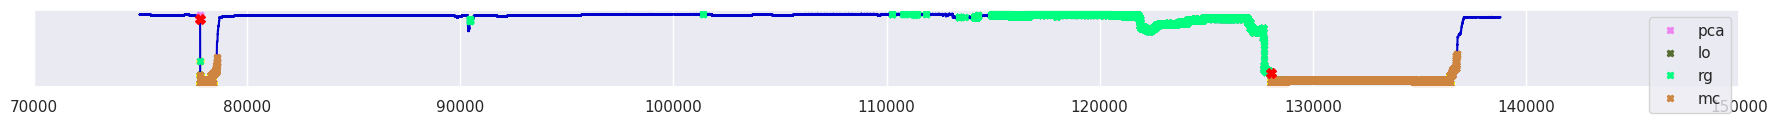

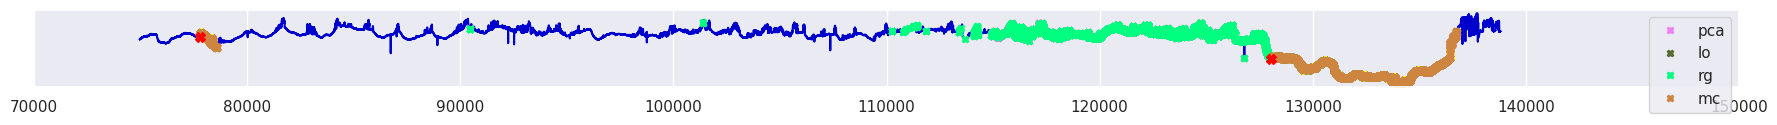

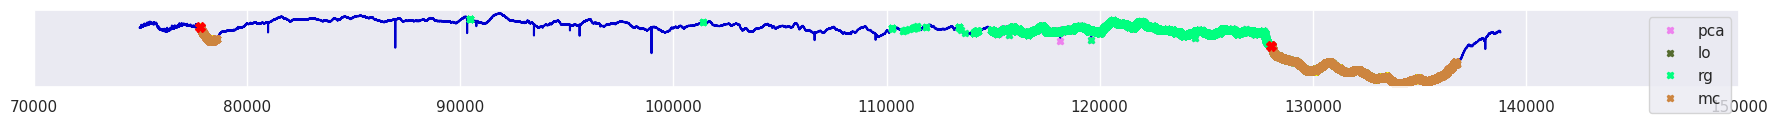

In [26]:
# this visualization was gratefully inspired by https://www.kaggle.com/code/mattison/water-pump-classification/notebook
if build_plots_full:
    col_names = df.columns[1:-1]
else:
    col_names = df.columns[1:4]
    
for col_name in col_names:
    plot = plt.figure(figsize=(22,1))
    plot = plt.plot(df_valid_split[col_name].loc[df_valid_split['machine_status'] == 2], linestyle='none', marker='o', color='yellow', markersize=5)
    plot = plt.plot(df_valid_split[col_name], color='mediumblue')
    plot = plt.plot(df_valid_split[col_name].loc[df_valid_split['outliers_pca'] == 1], linestyle='none', marker='X', color='violet', markersize=5, label='pca')
    plot = plt.plot(df_valid_split[col_name].loc[df_valid_split['outliers_lo'] == 1], linestyle='none', marker='X', color='darkolivegreen', markersize=5, label='lo')
    plot = plt.plot(df_valid_split[col_name].loc[df_valid_split['outliers_rg'] == 1], linestyle='none', marker='X', color='springgreen', markersize=5, label='rg')
    plot = plt.plot(df_valid_split[col_name].loc[df_valid_split['outliers_mc'] == 1], linestyle='none', marker='X', color='peru', markersize=5, label='mc')
    plot = plt.plot(df_valid_split[col_name].loc[df_valid_split['machine_status'] == 1], linestyle='none', marker='X', color='red', markersize=7)
    plt.legend(loc='upper right')
    plt.xlim((70000,150000))
    frame1 = plt.gca()
    frame1.axes.get_yaxis().set_visible(False)
    plt.show()

Similar to what we saw for the training data split, we can also see here that the MinClusterDetector with KMeans works best for the problem at hand and is able to realiably detect all anomalies (the pca-based detector reacts too slow in anomaly events and also produces some false positives, the regression detector also produces too many false positives, the local outlier detector is not able at all in this case to realiably detect the anomalies). Based on this, we determine the MinClusterDetector as our model of choice and will now use this model on the so far unseen test data!

## **Model Testing**
Below, we use the trained MinClusterDetector on the test data and then plot the results:

In [27]:
s_test = validate_series(df_test_split.set_index('timestamp'))
outliers_test_mc = min_cluster_ad.detect(s_test).astype(int)
df_test_split['outliers_mc'] = outliers_test_mc.to_numpy()

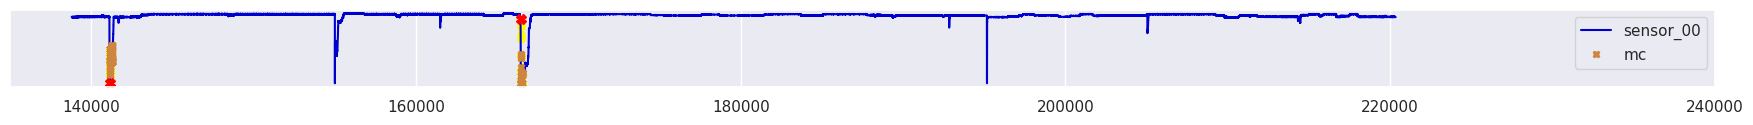

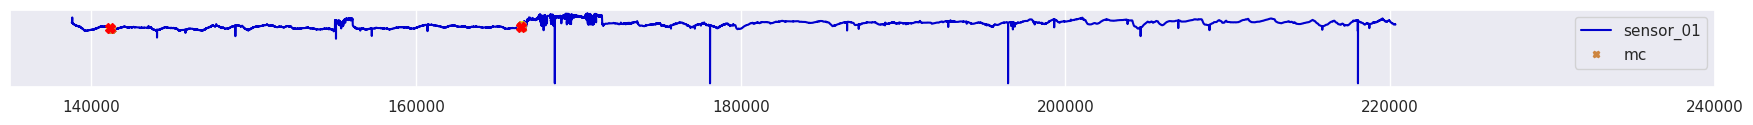

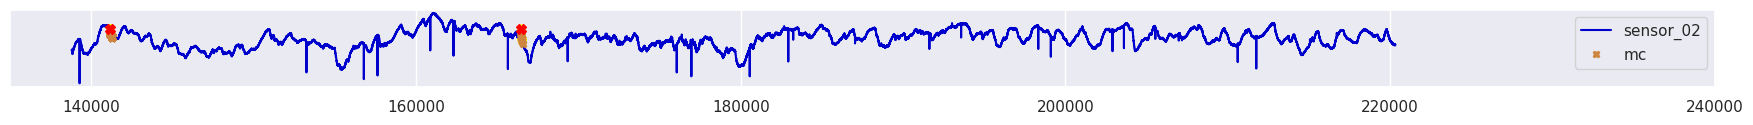

In [28]:
# this visualization was gratefully inspired by https://www.kaggle.com/code/mattison/water-pump-classification/notebook
if build_plots_full:
    col_names = df.columns[1:-1]
else:
    col_names = df.columns[1:4]
    
for col_name in col_names:   
    plot = plt.figure(figsize=(22,1))
    plot = plt.plot(df_test_split[col_name].loc[df_test_split['machine_status'] == 2], linestyle='none', marker='o', color='yellow', markersize=5)
    plot = plt.plot(df_test_split[col_name], color='mediumblue', label=col_name)
    plot = plt.plot(df_test_split[col_name].loc[df_test_split['outliers_mc'] == 1], linestyle='none', marker='X', color='peru', markersize=5, label='mc')
    plot = plt.plot(df_test_split[col_name].loc[df_test_split['machine_status'] == 1], linestyle='none', marker='X', color='red', markersize=7)
    plt.legend(loc='upper right')
    plt.xlim((135000,240000))
    frame1 = plt.gca()
    frame1.axes.get_yaxis().set_visible(False)
    plt.show()

We can see that our model is able to detect both anomalies and also does not produce any false positives for the test data. However, we can also see that the model on average takes 5 min to detect the anomalies here. In the context of having only one datapoint per minute, this performance seems to be good, but this delay is also important to be kept in mind when deploying the model. Even better would be to be able to predict the anomalies before they occure. This, however, shall be the content of a future notebook :).

## **Conclusion**
In summary, we successfully developed a model for detecting the anomalies (with no or considerably small delay). With this, we hope that we can already help the community which has problems through the failures of the pump system. Based on this model, in the future I would like to develop a model for predicting the anomalies before they even happen to potentially prevent the anomalies from happening in the first place.